In [17]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

In [18]:
def oracle(secret_code, n, qc):
    reversed_secrete_code = secret_code[::-1]
    for i in range(n):
        if reversed_secrete_code[i] == '1':
            qc.cx(i, n)
    qc.barrier()

In [19]:
def init_bernstein_vazirani(secret_code):
    n = len(secret_code)
    qc = QuantumCircuit(n+1, n)
    qc.h(range(n))
    qc.x(n)
    qc.h(n)
    qc.barrier()
    return secret_code, n, qc

In [20]:
def bernstein_vazirani(secret_code):
    secret_code, n, qc = init_bernstein_vazirani(secret_code)
    oracle(secret_code, n, qc)
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc

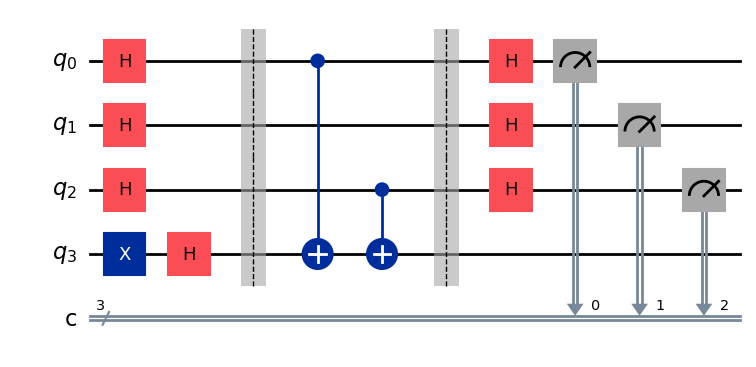

In [21]:
qc =bernstein_vazirani("101")
display(qc.draw('mpl'))

Results: {'101': 1024}


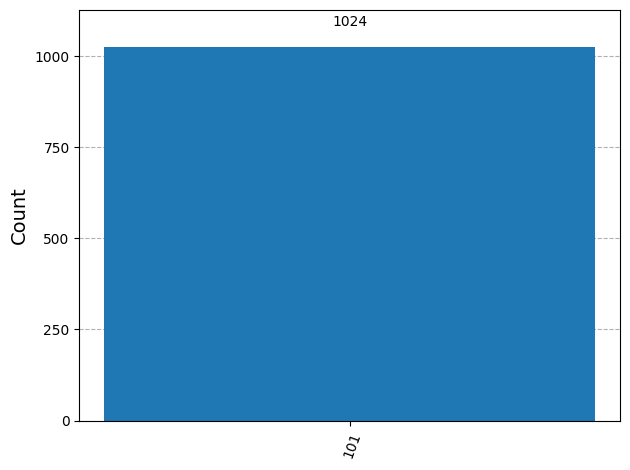

In [22]:
backend = Aer.get_backend('qasm_simulator')
transpile_qc = transpile(qc, backend)
job = backend.run(transpile_qc, shots=1024)
result = job.result()
counts = result.get_counts()
print(f"Results: {counts}")
display(plot_histogram(counts))